# hw4 - NN pyTorch

Во всем задании вы должны работать со входом из строк размером (длиной) 1024

## Часть 1 Фурье

### Подготовка данных

Сгенерите данные (сигнал) любым пакетом для численного преобразования Фурье, [например](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html#numpy.fft.fft)

In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import signal
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

np.random.seed(17)
torch.manual_seed(17)

In [15]:
# Параметры
N = 1000
BATCH_SIZE = 32
SIGNAL_LENGTH = 1024
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Генерирует сигнал (сумма синусоид с разными частотами)
def generate_signal(length=SIGNAL_LENGTH, num_components=5):
    t = np.linspace(0, 1, length)
    signal = np.zeros(length)

    for _ in range(num_components):
        freq = np.random.uniform(1, 50)  # Частота
        amplitude = np.random.uniform(0.5, 2.0)  # Амплитуда
        phase = np.random.uniform(0, 2 * np.pi)  # Фаза
        signal += amplitude * np.sin(2 * np.pi * freq * t + phase)

    # Шум
    noise = np.random.normal(0, 0.1, length)
    signal += noise

    return signal.astype(np.float32)


X_train = np.array([generate_signal() for _ in range(N)])
y_train = np.array([np.fft.fft(x) for x in X_train])

y_train_real = y_train.real.astype(np.float32)  # Действительная часть
y_train_imag = y_train.imag.astype(np.float32)  # Мнимая часть

y_train_combined = np.stack([y_train_real, y_train_imag], axis=1)

print(f"Форма X_train: {X_train.shape}")
print(f"Форма y_train_combined: {y_train_combined.shape}")

Форма X_train: (1000, 1024)
Форма y_train_combined: (1000, 2, 1024)


### Соберите и обучите нейросетку на pyTroch для преобразования Фурье

In [16]:
# Обучаем модель
def train_model(
    model,
    data_loader,
    loss_function,
    optimizer,
    n_epochs,
    device,
):
    model.to(device)
    model.train()
    training_metrics = []

    for epoch in range(n_epochs):
        cumulative_loss = 0.0
        progress_indicator = tqdm(data_loader, desc=f"Эпоха {epoch+1}/{n_epochs}")

        for temporal_inputs, spectral_targets in progress_indicator:
            temporal_inputs = temporal_inputs.to(device)
            spectral_targets = spectral_targets.to(device)

            optimizer.zero_grad()

            predicted_spectra = model(temporal_inputs)

            optimization_loss = loss_function(predicted_spectra, spectral_targets)

            optimization_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            current_loss = optimization_loss.item()
            cumulative_loss += current_loss
            progress_indicator.set_postfix({"текущая ошибка": current_loss})

        average_epoch_loss = cumulative_loss / len(data_loader)
        training_metrics.append(average_epoch_loss)
        print(f"Средняя ошибка: {average_epoch_loss:.6f}")

    return training_metrics


Модель FourierTransformer:
Общее количество параметров: 39,884,800

Запуск процедуры обучения...


Эпоха 1/25: 100%|██████████| 32/32 [00:10<00:00,  3.01it/s, текущая ошибка=2.26e+3]


Средняя ошибка: 2202.720982


Эпоха 2/25: 100%|██████████| 32/32 [00:10<00:00,  3.04it/s, текущая ошибка=2.04e+3]


Средняя ошибка: 2128.540340


...

Средняя ошибка: 820.458673


Эпоха 24/25: 100%|██████████| 32/32 [00:12<00:00,  2.60it/s, текущая ошибка=827]


Средняя ошибка: 780.288181


Эпоха 25/25: 100%|██████████| 32/32 [00:12<00:00,  2.59it/s, текущая ошибка=884]

Средняя ошибка: 746.419264


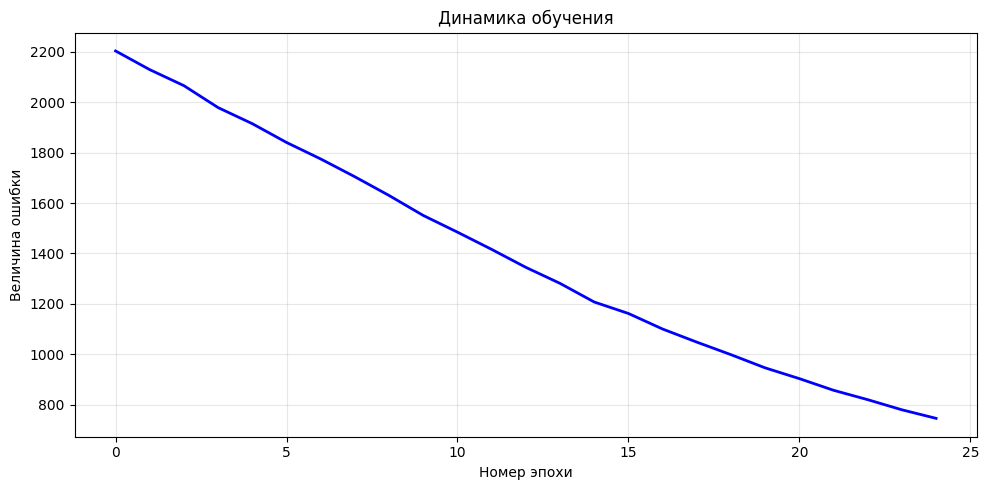


Финальная ошибка: 746.419264
Улучшение за обучение: 66.1%


In [17]:
class FourierTransformer(nn.Module):
    def __init__(self, input_size=SIGNAL_LENGTH, output_size=1024):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(2048),
            nn.Dropout(0.25),
            nn.Linear(2048, 4096),
            nn.ELU(),
            nn.BatchNorm1d(4096),
            nn.Dropout(0.25),
            nn.Linear(4096, 4096),
            nn.SiLU(),
            nn.BatchNorm1d(4096),
            nn.Dropout(0.25),
            nn.Linear(4096, 2048),
            nn.ReLU(),
            nn.BatchNorm1d(2048),
            nn.Dropout(0.25),
            nn.Linear(2048, 2 * output_size),
        )

    def forward(self, input_signal):
        spectral_output = self.feature_extractor(input_signal)
        batch_size = input_signal.size(0)
        return spectral_output.view(batch_size, 2, -1)


class FourierTrainingData(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.y[index]


model = FourierTransformer().to(DEVICE)
training_dataset = FourierTrainingData(X_train, y_train_combined)
data_loader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)

loss_function = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

print(f"\nМодель FourierTransformer:")
print(
    f"Общее количество параметров: " f"{sum(p.numel() for p in model.parameters()):,}"
)
print("\nЗапуск процедуры обучения...")

TOTAL_TRAINING_EPOCHS = 25
performance_history = train_model(
    model,
    data_loader,
    loss_function,
    optimizer,
    TOTAL_TRAINING_EPOCHS,
    DEVICE,
)

plt.figure(figsize=(10, 5))

plt.plot(performance_history, "b-", linewidth=2)
plt.xlabel("Номер эпохи")
plt.ylabel("Величина ошибки")
plt.title("Динамика обучения")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nФинальная ошибка: {performance_history[-1]:.6f}")
print(
    f"Улучшение за обучение: "
    f"{(performance_history[0] - performance_history[-1])/performance_history[0]*100:.1f}%"
)

### Сравните свое решение с пакетным методом

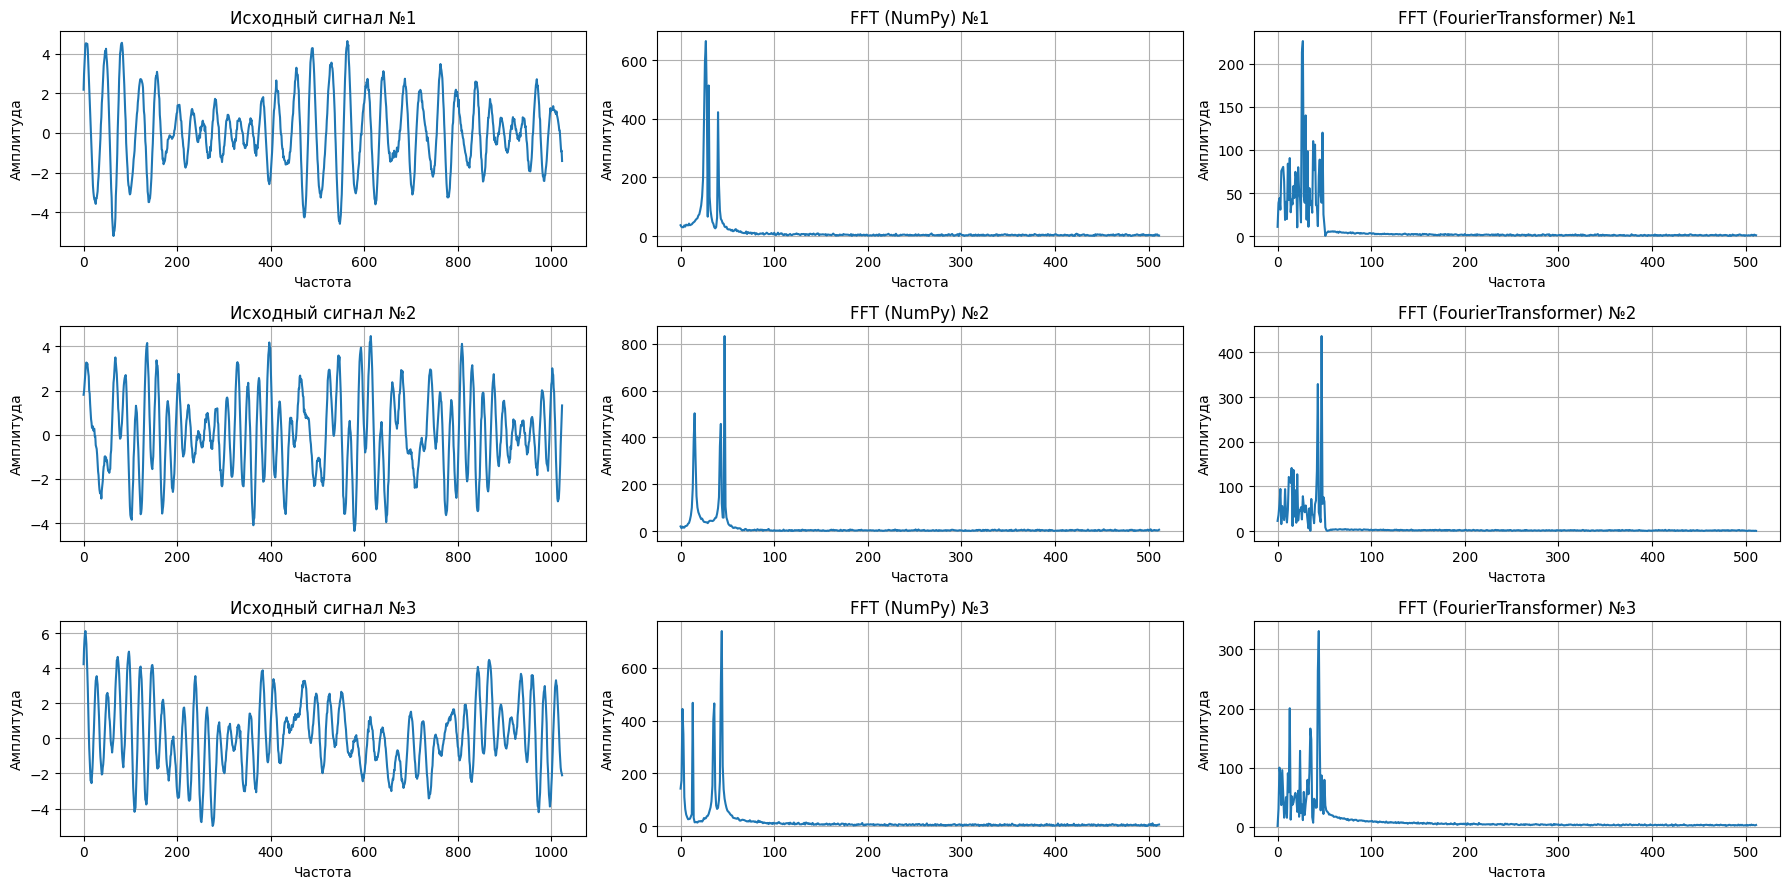


Сравнение FFT: NumPy vs FourierTransformer

Тестовый сигнал №1:
  MSE (действительная часть): 1336.2844
  MSE (мнимая часть): 993.3749
  MSE (амплитудный спектр): 2005.4790
  MAE (действительная часть): 9.0416
  MAE (мнимая часть): 8.8783
  MAE (амплитудный спектр): 8.1289
  Корреляция (амплитудный спектр): 0.752409

Тестовый сигнал №2:
  MSE (действительная часть): 554.7128
  MSE (мнимая часть): 882.4514
  MSE (амплитудный спектр): 1152.1901
  MAE (действительная часть): 6.1724
  MAE (мнимая часть): 8.7915
  MAE (амплитудный спектр): 5.4143
  Корреляция (амплитудный спектр): 0.875253

Тестовый сигнал №3:
  MSE (действительная часть): 1145.3730
  MSE (мнимая часть): 825.9620
  MSE (амплитудный спектр): 1564.2640
  MAE (действительная часть): 9.0128
  MAE (мнимая часть): 7.7027
  MAE (амплитудный спектр): 7.2209
  Корреляция (амплитудный спектр): 0.890021

Средние метрики:
  Средний MSE (действительная часть): 1012.1234
  Средний MSE (мнимая часть): 900.5960
  Средний MAE (действительн

In [18]:
# Сравним на 3 сгенерированных сигналах
n_test = 3
test_signals = np.array([generate_signal() for _ in range(n_test)])

model.eval()
with torch.no_grad():
    test_tensor = torch.tensor(test_signals, dtype=torch.float32).to(DEVICE)
    predictions = model(test_tensor).cpu().numpy()

# Вычисляем FFT с помощью Numpy
fft_numpy = np.array([np.fft.fft(sig) for sig in test_signals])

fig, axes = plt.subplots(n_test, 3, figsize=(18, 3 * n_test))

for i in range(n_test):
    # Амплитудный спектр от Numpy FFT
    fft_magnitude_numpy = np.abs(fft_numpy[i])

    # Амплитудный спектр от FourierTransformer
    fft_nn = predictions[i][0] + 1j * predictions[i][1]
    fft_magnitude_nn = np.abs(fft_nn)

    axes[i, 0].plot(test_signals[i])
    axes[i, 0].set_title(f"Исходный сигнал №{i+1}")
    axes[i, 0].set_xlabel("Частота")
    axes[i, 0].set_ylabel("Амплитуда")
    axes[i, 0].grid(True)

    axes[i, 1].plot(fft_magnitude_numpy[: SIGNAL_LENGTH // 2])
    axes[i, 1].set_title(f"FFT (NumPy) №{i+1}")
    axes[i, 1].set_xlabel("Частота")
    axes[i, 1].set_ylabel("Амплитуда")
    axes[i, 1].grid(True)

    axes[i, 2].plot(fft_magnitude_nn[: SIGNAL_LENGTH // 2])
    axes[i, 2].set_title(f"FFT (FourierTransformer) №{i+1}")
    axes[i, 2].set_xlabel("Частота")
    axes[i, 2].set_ylabel("Амплитуда")
    axes[i, 2].grid(True)

plt.tight_layout()
plt.show()

print("\nСравнение FFT: NumPy vs FourierTransformer\n")
for i in range(n_test):
    fft_nn = predictions[i][0] + 1j * predictions[i][1]

    # MSE между действительными частями
    mse_real = np.mean((fft_numpy[i].real - predictions[i][0]) ** 2)

    # MSE между мнимыми частями
    mse_imag = np.mean((fft_numpy[i].imag - predictions[i][1]) ** 2)

    # MSE для амплитудных спектров
    mse_magnitude = np.mean((np.abs(fft_numpy[i]) - np.abs(fft_nn)) ** 2)

    # MAE между действительными частями
    mae_real = np.mean(np.abs(fft_numpy[i].real - predictions[i][0]))

    # MAE между мнимыми частями
    mae_imag = np.mean(np.abs(fft_numpy[i].imag - predictions[i][1]))

    # MAE для амплитудных спектров
    mae_magnitude = np.mean(np.abs(fft_numpy[i]) - np.abs(fft_nn))

    # Корреляция между амплитудными спектрами
    correlation = np.corrcoef(np.abs(fft_numpy[i]), np.abs(fft_nn))[0, 1]

    print(f"Тестовый сигнал №{i+1}:")
    print(f"  MSE (действительная часть): {mse_real:.4f}")
    print(f"  MSE (мнимая часть): {mse_imag:.4f}")
    print(f"  MSE (амплитудный спектр): {mse_magnitude:.4f}")
    print(f"  MAE (действительная часть): {mae_real:.4f}")
    print(f"  MAE (мнимая часть): {mae_imag:.4f}")
    print(f"  MAE (амплитудный спектр): {mae_magnitude:.4f}")
    print(f"  Корреляция (амплитудный спектр): {correlation:.6f}")
    print()

# Среднее по всем тестовым сигналам
avg_mse_real = np.mean(
    [np.mean((fft_numpy[i].real - predictions[i][0]) ** 2) for i in range(n_test)]
)
avg_mse_imag = np.mean(
    [np.mean((fft_numpy[i].imag - predictions[i][1]) ** 2) for i in range(n_test)]
)
avg_mae_real = np.mean(
    [np.mean(fft_numpy[i].real - predictions[i][0]) for i in range(n_test)]
)
avg_mae_imag = np.mean(
    [np.mean(fft_numpy[i].imag - predictions[i][1]) for i in range(n_test)]
)
avg_correlation = np.mean(
    [
        np.corrcoef(
            np.abs(fft_numpy[i]), np.abs(predictions[i][0] + 1j * predictions[i][1])
        )[0, 1]
        for i in range(n_test)
    ]
)

print(f"Средние метрики:")
print(f"  Средний MSE (действительная часть): {avg_mse_real:.4f}")
print(f"  Средний MSE (мнимая часть): {avg_mse_imag:.4f}")
print(f"  Средний MAE (действительная часть): {avg_mae_real:.4f}")
print(f"  Средний MAE (мнимая часть): {avg_mae_imag:.4f}")
print(f"  Средняя корреляция (амплитудный спектр): {avg_correlation:.6f}")

## Часть 2 Power spectral density (dB)

### Подготовка данных

Используя пакетное решение, [например](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html), подготовьте обучающую выборку.

Генерация обучающей выборки для PSD...
Форма X_train_psd: (5000, 1024)
Форма y_train_psd: (5000, 513)

Длина входа: 1024
Длина выхода: 513


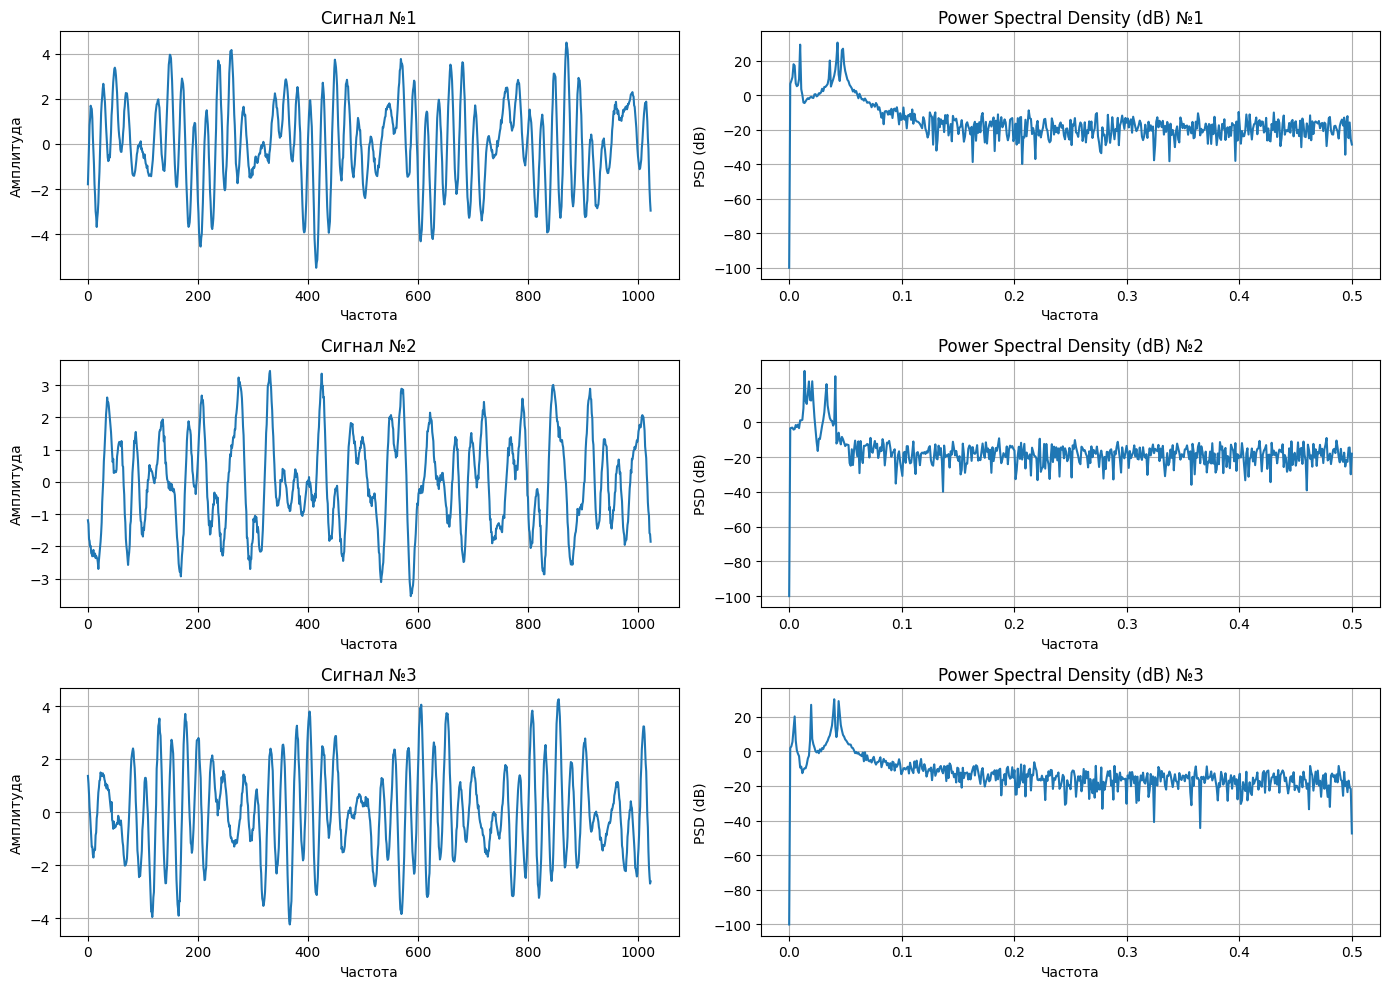

In [67]:
# Генерация обучающей выборки для PSD
print("Генерация обучающей выборки для PSD...")

X_train_psd = np.array([generate_signal() for _ in range(5 * N)])

# periodogram возвращает частоты и плотности мощности
y_train_psd = []

for sig in X_train_psd:
    freqs, psd = signal.periodogram(sig, fs=1.0, scaling="density")
    psd_db = 10 * np.log10(psd + 1e-10)
    y_train_psd.append(psd_db)

y_train_psd = np.array(y_train_psd, dtype=np.float32)

print(f"Форма X_train_psd: {X_train_psd.shape}")
print(f"Форма y_train_psd: {y_train_psd.shape}")
print()
print(f"Длина входа: {X_train_psd.shape[1]}")
print(f"Длина выхода: {y_train_psd.shape[1]}")

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i in range(3):
    # Исходный сигнал
    axes[i, 0].plot(X_train_psd[i])
    axes[i, 0].set_title(f"Сигнал №{i+1}")
    axes[i, 0].set_xlabel("Частота")
    axes[i, 0].set_ylabel("Амплитуда")
    axes[i, 0].grid(True)

    # PSD в dB
    freqs, _ = signal.periodogram(X_train_psd[i], fs=1.0, scaling="density")
    axes[i, 1].plot(freqs, y_train_psd[i])
    axes[i, 1].set_title(f"Power Spectral Density (dB) №{i+1}")
    axes[i, 1].set_xlabel("Частота")
    axes[i, 1].set_ylabel("PSD (dB)")
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

### Соберите и обучите нейросеть для предсказания спектральной плотности мощности

*Подсказка: для входа 1024 выход будет 512*


Модель PSDTransformer:
Общее количество параметров: 9,192,961

Запуск процедуры обучения...


Эпоха 1/25: 100%|██████████| 157/157 [00:12<00:00, 12.20it/s, текущая ошибка=57.5]


Средняя ошибка: 145.473822


Эпоха 2/25: 100%|██████████| 157/157 [00:12<00:00, 12.56it/s, текущая ошибка=43.9]


Средняя ошибка: 49.505583


...

Средняя ошибка: 32.193624


Эпоха 24/25: 100%|██████████| 157/157 [00:11<00:00, 13.40it/s, текущая ошибка=32.1]


Средняя ошибка: 31.964547


Эпоха 25/25: 100%|██████████| 157/157 [00:11<00:00, 13.88it/s, текущая ошибка=35.4]


Средняя ошибка: 31.823566


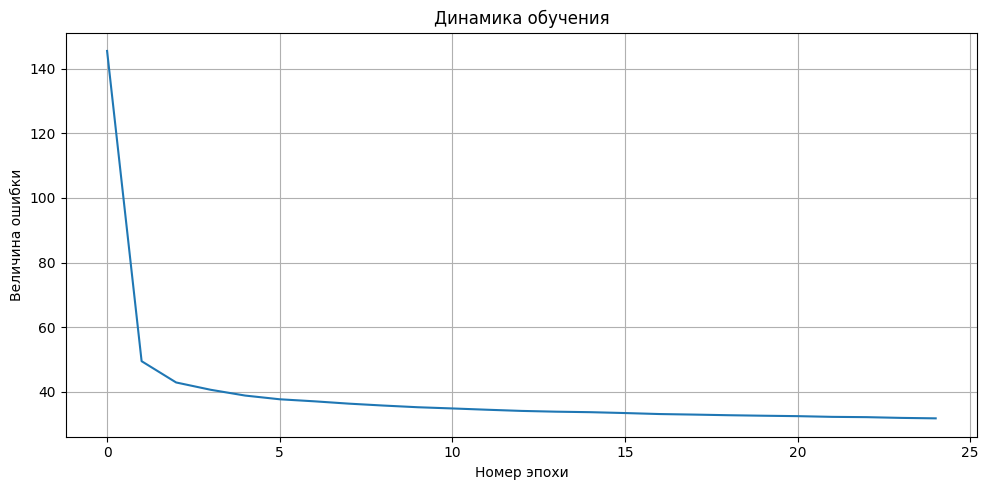


Финальная ошибка: 31.823566
Улучшение за обучение: 78.1%


In [69]:
class PSDTransformer(nn.Module):
    def __init__(self, input_size=SIGNAL_LENGTH, output_size=513):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.BatchNorm1d(2048),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(2048, 2048),
            nn.BatchNorm1d(2048),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, output_size),
        )

    def forward(self, input_signal):
        return self.network(input_signal)


class PSDTrainingData(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.y[index]


psd_dataset = PSDTrainingData(X_train_psd, y_train_psd)
data_loader = DataLoader(psd_dataset, batch_size=BATCH_SIZE, shuffle=True)

model = PSDTransformer().to(DEVICE)
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"\nМодель PSDTransformer:")
print(
    f"Общее количество параметров: " f"{sum(p.numel() for p in model.parameters()):,}"
)
print("\nЗапуск процедуры обучения...")

TOTAL_TRAINING_EPOCHS = 25
performance_history = train_model(
    model, data_loader, loss_function, optimizer, TOTAL_TRAINING_EPOCHS, DEVICE
)

plt.figure(figsize=(10, 5))

plt.plot(performance_history)
plt.xlabel("Номер эпохи")
plt.ylabel("Величина ошибки")
plt.title("Динамика обучения")
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nФинальная ошибка: {performance_history[-1]:.6f}")
print(
    f"Улучшение за обучение: "
    f"{(performance_history[0] - performance_history[-1])/performance_history[0]*100:.1f}%"
)

### Провалидируйте свое решение

*Примечание: Для сдачи достаточно качественного соответствия по форме спектра с пакетным решением*

In [86]:
def access_model(correlation):
    quality = "ПЛОХО - нужна другая модель"

    if correlation > 0.90:
        quality = "ПРЕВОСХОДНО"
    elif correlation > 0.80:
        quality = "ОТЛИЧНО"
    elif correlation > 0.70:
        quality = "ХОРОШО"
    elif correlation > 0.60:
        quality = "УДОВЛЕТВОРИТЕЛЬНО"

    return quality

C:\Users\MrWh1teF0x\AppData\Local\Temp\ipykernel_20484\1587645572.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i, 1].legend()
C:\Users\MrWh1teF0x\AppData\Local\Temp\ipykernel_20484\1587645572.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i, 2].legend()


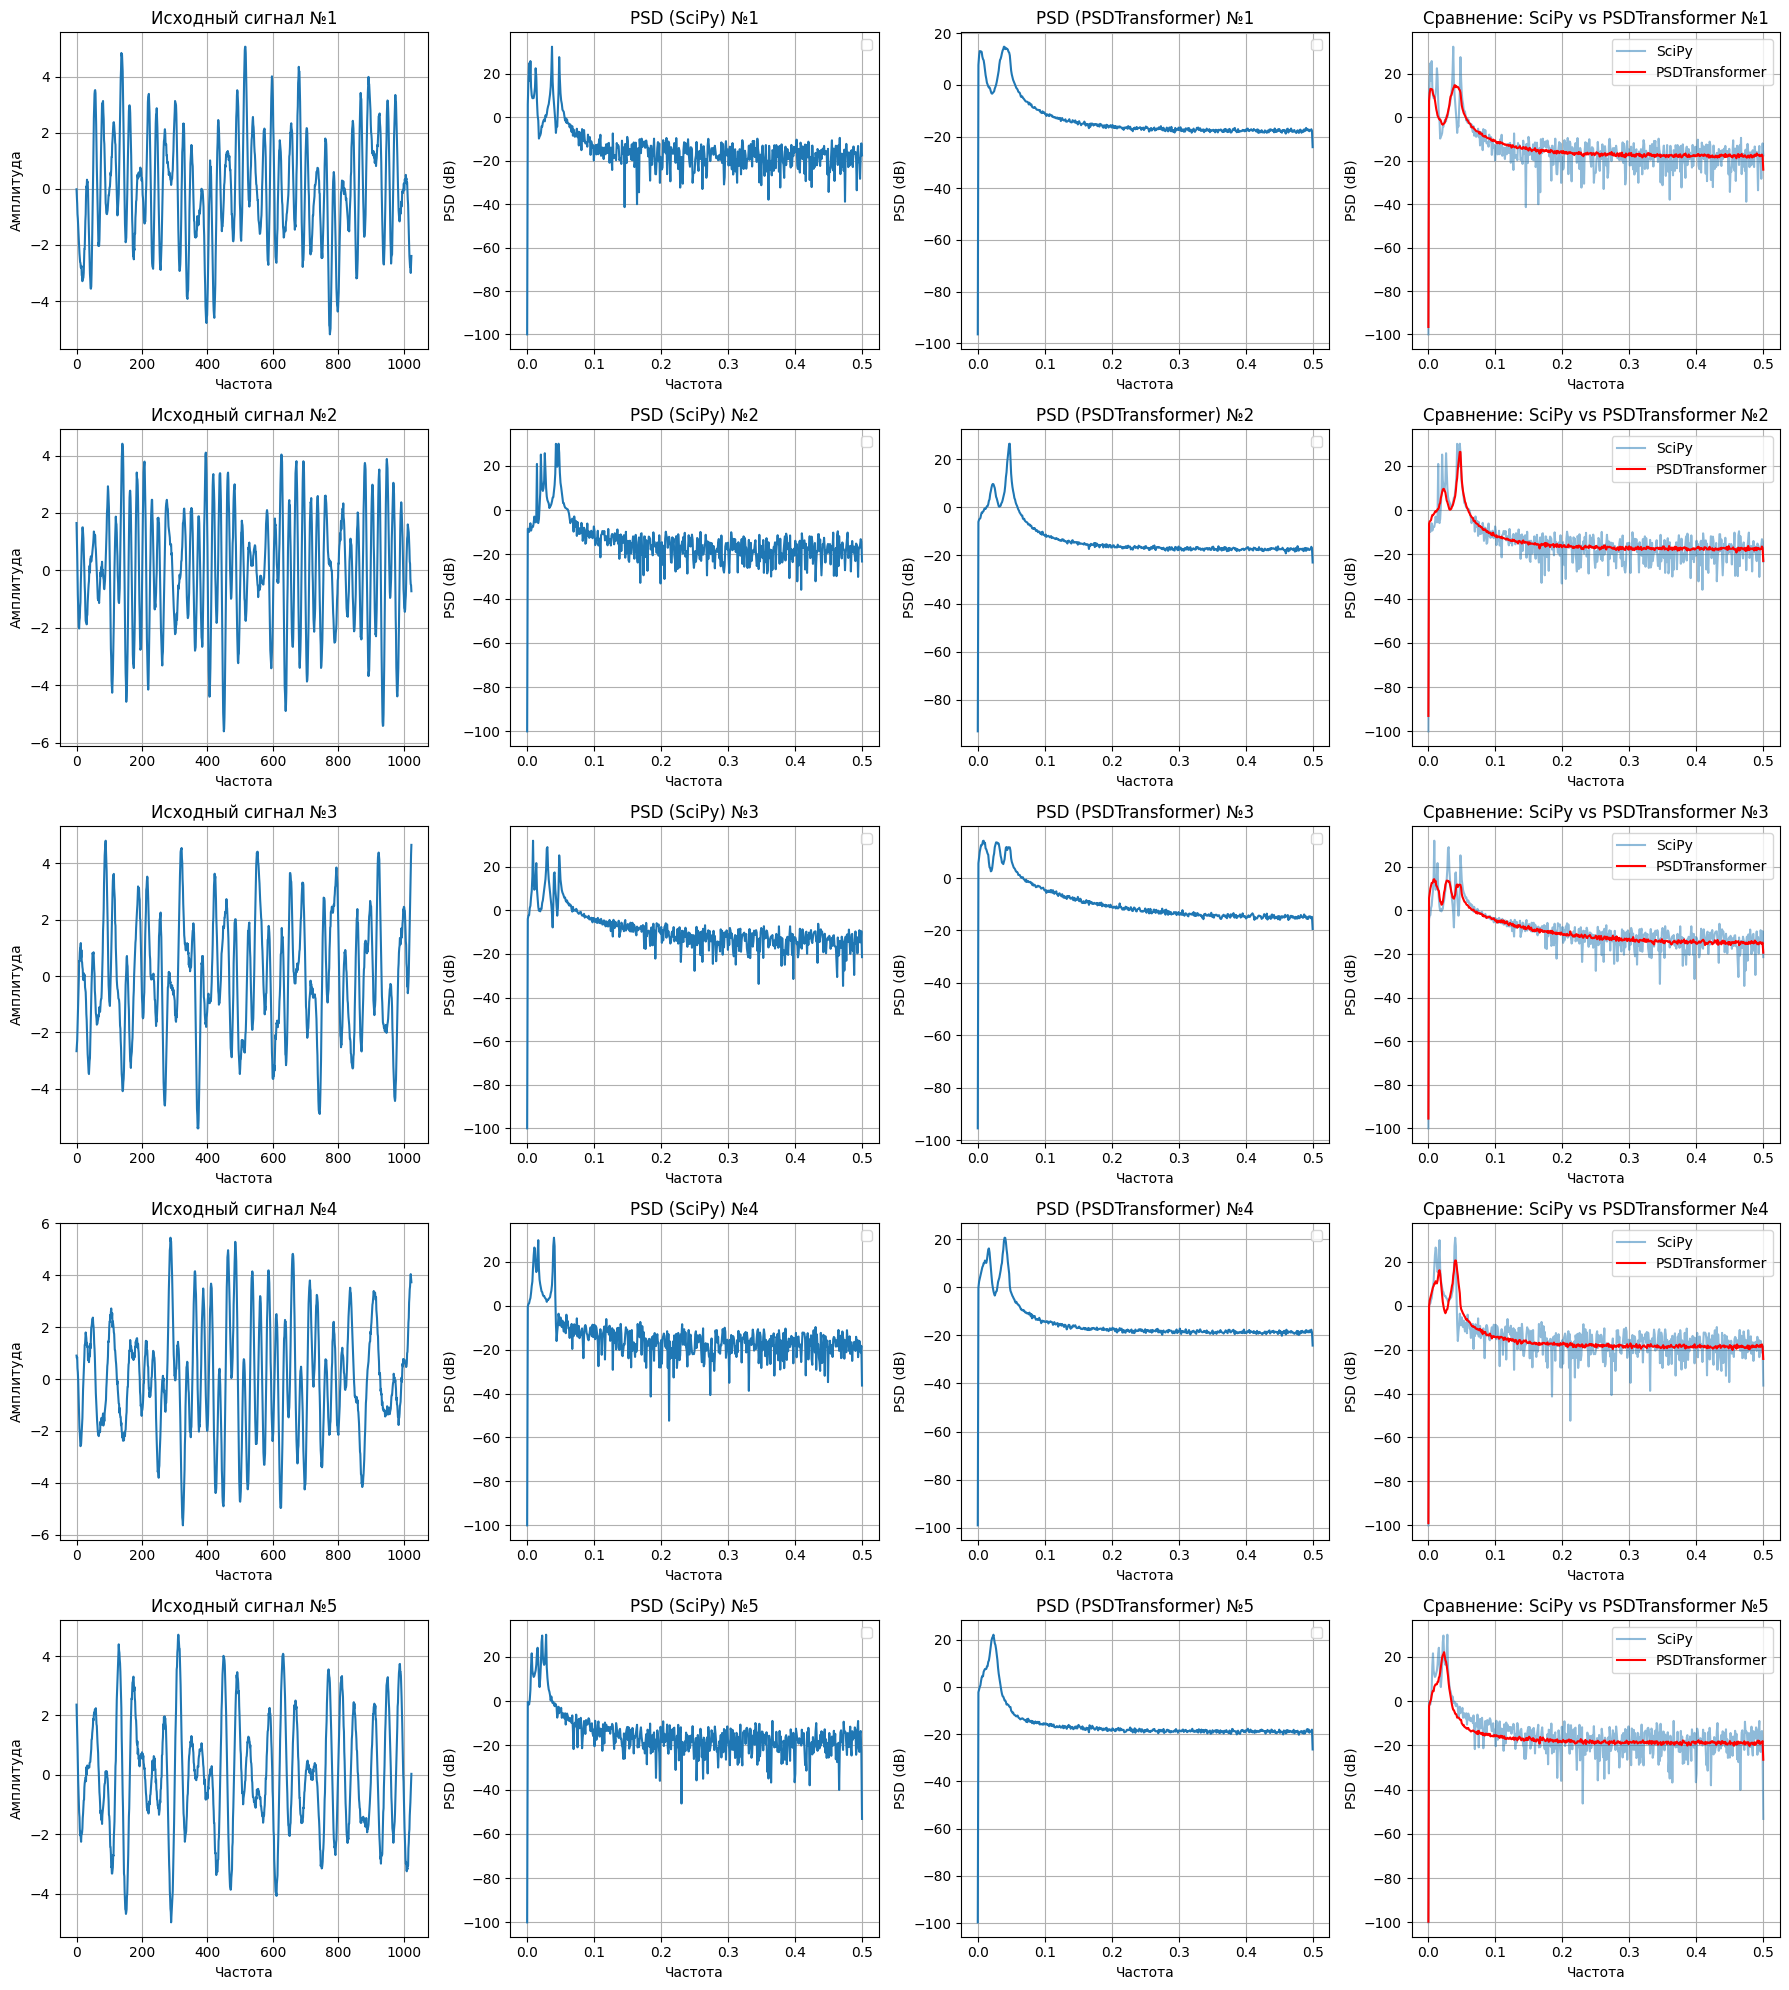


Сравнение PSD: Scipy vs PSDTransformer

Тестовый сигнал №1:
  MSE: 33.7940
  MAE: -1.0321
  Корреляция: 0.704489
  Оценка модели: ХОРОШО

Тестовый сигнал №2:
  MSE: 25.7330
  MAE: -0.8424
  Корреляция: 0.759336
  Оценка модели: ХОРОШО

Тестовый сигнал №3:
  MSE: 20.4175
  MAE: -0.0551
  Корреляция: 0.789278
  Оценка модели: ХОРОШО

Тестовый сигнал №4:
  MSE: 36.3883
  MAE: 0.0471
  Корреляция: 0.672011
  Оценка модели: УДОВЛЕТВОРИТЕЛЬНО

Тестовый сигнал №5:
  MSE: 33.4645
  MAE: 0.5923
  Корреляция: 0.678089
  Оценка модели: УДОВЛЕТВОРИТЕЛЬНО

Средние метрики:
  Средний MSE: 6780.3501
  Средний MAE: 24.1989
  Средняя корреляция: 0.720641
  Средняя оценка модели: ХОРОШО


In [111]:
# Сравним на 5 сгенерированных сигналах
n_test = 5
test_signals = np.array([generate_signal() for _ in range(n_test)])

model.eval()
with torch.no_grad():
    test_tensor = torch.tensor(test_signals, dtype=torch.float32).to(DEVICE)
    psd_predictions = model(test_tensor).cpu().numpy()

# Вычисляем PSD с помощью Scipy
psd_scipy = []
freqs_list = []

for sig in test_signals:
    freqs, psd = signal.periodogram(sig, fs=1.0, scaling="density")
    psd_db = 10 * np.log10(psd + 1e-10)
    psd_scipy.append(psd_db)
    freqs_list.append(freqs)

psd_scipy = np.array(psd_scipy)

fig, axes = plt.subplots(n_test, 4, figsize=(18, 4 * n_test))

for i in range(n_test):
    axes[i, 0].plot(test_signals[i])
    axes[i, 0].set_title(f"Исходный сигнал №{i+1}")
    axes[i, 0].set_xlabel("Частота")
    axes[i, 0].set_ylabel("Амплитуда")
    axes[i, 0].grid(True)

    axes[i, 1].plot(freqs_list[i], psd_scipy[i])
    axes[i, 1].set_title(f"PSD (SciPy) №{i+1}")
    axes[i, 1].set_xlabel("Частота")
    axes[i, 1].set_ylabel("PSD (dB)")
    axes[i, 1].grid(True)
    axes[i, 1].legend()

    axes[i, 2].plot(
        freqs_list[i],
        psd_predictions[i],
    )
    axes[i, 2].set_title(f"PSD (PSDTransformer) №{i+1}")
    axes[i, 2].set_xlabel("Частота")
    axes[i, 2].set_ylabel("PSD (dB)")
    axes[i, 2].grid(True)
    axes[i, 2].legend()

    axes[i, 3].plot(
        freqs_list[i],
        psd_scipy[i],
        linewidth=1.5,
        alpha=0.5,
        label="SciPy",
    )
    axes[i, 3].plot(
        freqs_list[i], psd_predictions[i], "r", linewidth=1.5, label="PSDTransformer"
    )
    axes[i, 3].set_title(f"Сравнение: SciPy vs PSDTransformer №{i+1}")
    axes[i, 3].set_xlabel("Частота")
    axes[i, 3].set_ylabel("PSD (dB)")
    axes[i, 3].grid(True)
    axes[i, 3].legend()

plt.tight_layout()
plt.show()

print("\nСравнение PSD: Scipy vs PSDTransformer\n")
for i in range(n_test):
    # MSE
    mse_real = np.mean((psd_scipy[i] - psd_predictions[i]) ** 2)

    # MAE
    mse_imag = np.mean(psd_scipy[i] - psd_predictions[i])

    # Корреляция
    correlation = np.corrcoef(np.abs(psd_scipy[i]), np.abs(psd_predictions[i]))[0, 1]

    print(f"Тестовый сигнал №{i+1}:")
    print(f"  MSE: {mse_real:.4f}")
    print(f"  MAE: {mse_imag:.4f}")
    print(f"  Корреляция: {correlation:.6f}")
    print(f"  Оценка модели: {access_model(correlation)}")
    print()

# Среднее по всем тестовым сигналам
avg_mse = np.mean(
    [np.mean((psd_scipy[i] - psd_predictions[i]) ** 2) for i in range(n_test)]
)

avg_mae = np.mean([np.mean(psd_scipy[i] - psd_predictions[i]) for i in range(n_test)])

avg_correlation = np.mean(
    [
        np.corrcoef(np.abs(psd_scipy[i]), np.abs(psd_predictions[i]))[0, 1]
        for i in range(n_test)
    ]
)

print(f"Средние метрики:")
print(f"  Средний MSE: {avg_mse_real:.4f}")
print(f"  Средний MAE: {avg_mse_imag:.4f}")
print(f"  Средняя корреляция: {avg_correlation:.6f}")
print(f"  Средняя оценка модели: {access_model(avg_correlation)}")